# Exploratory Data Analyis

To run this notebook first set up `config.yaml` to point to the intended source and review folders (either by editing  `config.yaml` directly, or running `launch_annotator.bat`).

Then we can do the following:

* Check source metadata and any source annotation files load OK
* Check that the settings file `config.yaml' exists and loads OK, otherwise build a new default one with the demo data
* Check the source locations & plot their positions on a basemap
* Interactively select and save a basemap for the annotation notebook  

Olly's TODO list:
* Validate data-types for the source data against the Anqa data schema
* Plot class distributions of any previously annotated data
* Plot class distributions of total annotated data including new annotations
* Check the class names of any annotations, 'primary_label' and 'secondary_labels' in the source data
* Compare those names against the names used in the naming schema csv file

In [ ]:
import yaml
from pathlib import Path
import pandas as pd
import contextily as cx
from contextily.tile import _calculate_zoom
import matplotlib.pyplot as plt
import numpy as np
from operator import attrgetter
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FutureTimeoutError
from IPython.display import display
from anqa.annotation import load_labels, normalize_secondary_labels
from anqa.config_editor import save_config
from anqa.basemaps import (save_region_map, plot_points_on_cx_basemap,
                           plot_points_on_saved_basemap, populate_random_points,
                           validate_wgs84)

In [2]:
project_root = str(Path().resolve().parent.parent)
yaml_path = Path(project_root) / 'project' / 'config.yaml'
new_region_name = None #None  #Set this, eg. 'mount_doom' to create a new geographic region (or add directly to config.yaml)

## 1. Validate `config.yaml`

In [3]:
use_case = {}

default_extents = {'new_zealand': 
                                        {'min_longitude': 166,
                                         'max_longitude': 179, # -170 ,  #179
                                         'min_latitude': -49,
                                         'max_latitude': -34},
                 'south_america':
                                         {'min_longitude': -82.0,
                                          'max_longitude': -34.0,
                                          'min_latitude': -56.0,
                                          'max_latitude': 13.0
                                         }
                                        }

try:
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
        source_dataset_path = cfg["source_dataset_path"]
        use_case = {
                'project_root': project_root,
                'source_dataset_path': source_dataset_path,
                'reviewed_data_destn': cfg["reviewed_data_destn"],
                'naming_csv': cfg["naming_csv"],
                'author': cfg["author"],
                'reviewer': cfg["reviewer"],
                'audio_folder': cfg["audio_folder"],
                'region': cfg['map_extents'],
                'geographic_extents': cfg['geographic_extents']
}
except Exception as e:
    print(f"Details: {e}")
    print("⚠️ There's a problem with config.yaml — A new default template will be created" \
          " you can edit this manually, or with the annotation launcher, then re-run the notebook")

    default_yaml = {
                'project_root': project_root,
                'source_dataset_path': project_root + '/data/demo_source',
                'reviewed_data_destn': project_root + '/data/demo_source_reviewed',
                'audio_folder': project_root + '/data/demo_source/audio',
                'naming_csv':  project_root + '/data/bird_names/bird_names.csv',
                'display_width': 16,
                'author': 'El Chupanibre',
                'reviewer': 'Alicanto',
                'region': 'new_zealand',
                'geographic_extents': default_extents
                }

    save_config(default_yaml)  #I'm not happy about this, let's add an explicit filepath
    use_case = default_yaml

load_samples = False
items = [display(item) for item in use_case.items()]

Details: 'map_extents'
⚠️ There's a problem with config.yaml — A new default template will be created you can edit this manually, or with the annotation launcher, then re-run the notebook


('project_root', 'C:\\Users\\ollyp\\OneDrive\\Desktop\\anqa')

('source_dataset_path',
 'C:\\Users\\ollyp\\OneDrive\\Desktop\\anqa/data/demo_source')

('reviewed_data_destn',
 'C:\\Users\\ollyp\\OneDrive\\Desktop\\anqa/data/demo_source_reviewed')

('audio_folder',
 'C:\\Users\\ollyp\\OneDrive\\Desktop\\anqa/data/demo_source/audio')

...

('display_width', 16)

('author', 'El Chupanibre')

('reviewer', 'Alicanto')

('region', 'new_zealand')

('geographic_extents',
 {'new_zealand': {'min_longitude': 166,
   'max_longitude': 179,
   'min_latitude': -49,
   'max_latitude': -34},
  'south_america': {'min_longitude': -82.0,
   'max_longitude': -34.0,
   'min_latitude': -56.0,
   'max_latitude': 13.0}})

In [4]:
class FilePaths:
    def __init__(self, options: dict):
        _project_dir = Path(options['project_root'])
        self.original_dataset = Path(options['source_dataset_path'])
        self.data_folder = _project_dir / 'data'
        self.audio_folder = options.get('audio_folder', self.data_folder)
        _metadata_files = [f for ext in ('csv', 'parquet') for f in self.original_dataset.glob(f'metadata.{ext}')]
        _label_files = [f for ext in ('csv', 'parquet') for f in self.original_dataset.glob(f'annotations.{ext}')]
        if len(_metadata_files) == 0:
            raise ValueError(f'No metadata.csv or metadata.parquet found in {self.original_dataset}')
        if len(_metadata_files) > 1:
            raise ValueError(f'Found both metadata.csv and metadata.parquet in {self.original_dataset} — ambiguous')
        if len(_label_files) > 1:
            raise ValueError(f'Found both metadata.csv and metadata.parquet in {self.original_dataset} — ambiguous')
        self.original_labels = _label_files[0] if len(_label_files) == 1 else None
        self.original_metadata = _metadata_files[0]
        self.out_dataset = Path(options['reviewed_data_destn'])
        self.out_dataset.mkdir(exist_ok=True, parents=True)
        self.out_labels = self.out_dataset / 'annotations.parquet'
        self.out_metadata = self.out_dataset / 'metadata.parquet'
        self.maps_dir = self.data_folder / 'basemaps'
        self.naming_csv = Path(options['naming_csv'])

paths = FilePaths(use_case)

if new_region_name is None:
    geo_name = use_case['region']
    extents = use_case['geographic_extents'][geo_name]
else:
    geo_name = new_region_name
    first_region = next(iter(default_extents))
    extents = default_extents[first_region]

## 2. Validate the Source Metadata

In [5]:
if paths.original_metadata.suffix == '.csv':
    df_meta = pd.read_csv(paths.original_metadata)
else:
    df_meta = pd.read_parquet(paths.original_metadata)

df_meta = df_meta.sort_values(by='filename')  #Ensures all the files from one class folder are presented sequentially
df_meta['secondary_labels'] = df_meta['secondary_labels'].apply(normalize_secondary_labels)
df_meta['longitude'] = [None]*len(df_meta)
df_meta['latitude'] = [None]*len(df_meta)
df_meta.head(3)

,filename,collection,secondary_labels,url,latitude,longitude,author,license,recorded_on,reviewed_by,reviewed_on,source_filename,source_start_s,source_end_s,models_used
30,20190831_074504_from_0.flac,NaN,[],NaN,None,None,Sumudu,NaN,2019-08-31 07:45:04,NaN,NaN,20190831_074504.wav,0.0,60.0,NaN
32,20190831_074504_from_120.flac,NaN,[],NaN,None,None,Sumudu,NaN,2019-08-31 07:45:04,NaN,NaN,20190831_074504.wav,120.0,180.0,NaN
33,20190831_074504_from_180.flac,NaN,[],NaN,None,None,Sumudu,NaN,2019-08-31 07:45:04,NaN,NaN,20190831_074504.wav,180.0,240.0,NaN


In [6]:
#If no spatial data is found, some random points will be created for setup purposes.
results = validate_wgs84(df_meta)
#results

0/45 rows have valid WGS84 lat/lon values.


In [7]:
extents

{'min_longitude': 166,
 'max_longitude': 179,
 'min_latitude': -49,
 'max_latitude': -34}

If there is no valid spatial data at all, let's randomly assign some for now, just so that the visualisation workflow runs

In [ ]:
if results["n_valid"] == 0:
    df_meta = populate_random_points(df_meta, extents)
    results = validate_wgs84(df_meta)
    #df_meta.to_parquet(paths.original_metadata)
    display(results)

166 179
Populated 45 row(s) with random points within extents {'min_longitude': 166, 'max_longitude': 179, 'min_latitude': -49, 'max_latitude': -34}.
45/45 rows have valid WGS84 lat/lon values.


{'valid': True, 'n_valid': np.int64(45), 'n_total': 45, 'warnings': []}

## Chose basemap style & check sample spatial data
Let's start by taking a look at some suitable base-map styles for the annotator

In [13]:
#display(cx.providers.flatten())

In [14]:
xmin, ymin = extents["min_longitude"], extents["min_latitude"]
xmax, ymax = extents["max_longitude"], extents["max_latitude"]

display(f'Longitude of western extent {xmin}')
display(f'Longitude of eastern extent {xmax}')

'Longitude of western extent 166'

'Longitude of eastern extent 179'

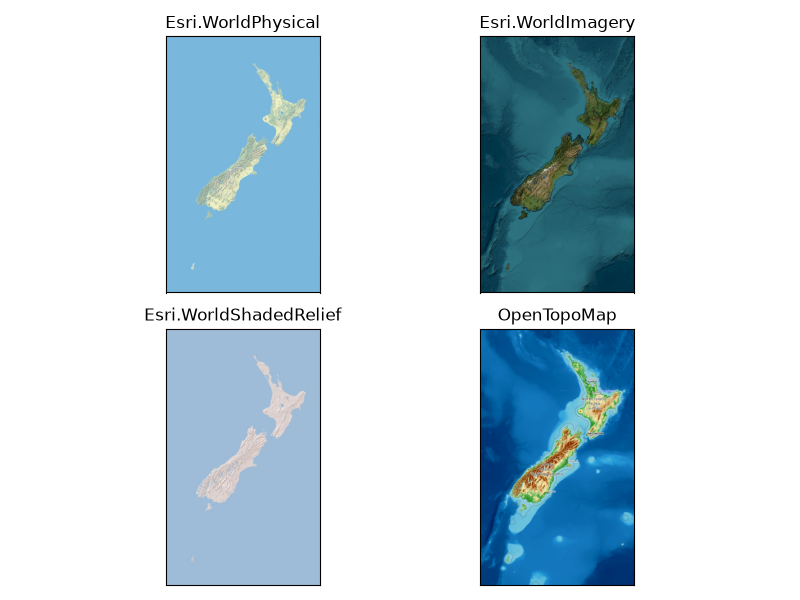

In [24]:
HARD_TIMEOUT = 20

include = ['Esri.WorldPhysical',
           #'Esri.WorldTerrain',
           'Esri.WorldImagery',
           'Esri.WorldShadedRelief',
           #'CartoDB.Positron',
           'OpenTopoMap',
           ]


def fetch(provider):
    if xmin > xmax:
        # pick one zoom level based on total antimeridian-spanning width,
        # so both halves come back at matching resolution
        total_width = (180 - xmin) + (xmax - (-180))
        zoom = _calculate_zoom(0, ymin, total_width, ymax)

        img_west, ext_west = cx.bounds2img(
            xmin, ymin, 180, ymax, zoom=zoom, source=provider, ll=True,
            n_connections=1, timeout=10,
        )
        img_east, ext_east = cx.bounds2img(
            -180, ymin, xmax, ymax, zoom=zoom, source=provider, ll=True,
            n_connections=1, timeout=10,
        )
        img = np.concatenate([img_west, img_east], axis=1)
        # extent is (left, right, bottom, top) in Web Mercator meters;
        # bottom/top are identical for both halves since ymin/ymax match

        print(f'The image shape is {img.shape}')
        extent = (ext_west[0], ext_east[1], ext_west[2], ext_west[3])
        return img, extent
    else:
        return cx.bounds2img(
            xmin, ymin, xmax, ymax, source=provider, ll=True,
            n_connections=1, timeout=10,
        )

fig, axes = plt.subplots(2, len(include) // 2, figsize=(4 * len(include) // 2,6))

with ThreadPoolExecutor(max_workers=1) as pool:
    for ax, name in zip(axes.flatten(), include):
        provider = attrgetter(name)(cx.providers)
        ax.set_title(name)
        ax.set_xticks([])
        ax.set_yticks([])
        future = pool.submit(fetch, provider)
        try:
            img, extent = future.result(timeout=HARD_TIMEOUT)
            ax.imshow(img)  #, extent=extent
        except FutureTimeoutError:
            ax.text(0.5, 0.5, "unavailable\n(timed out)", ha="center", va="center",
                     transform=ax.transAxes, fontsize=9, color="gray")
            ax.set_facecolor("#f0f0f0")
        except Exception as e:
            ax.text(0.5, 0.5, f"unavailable\n({type(e).__name__})", ha="center", va="center",
                     transform=ax.transAxes, fontsize=9, color="gray")
            ax.set_facecolor("#f0f0f0")

plt.tight_layout()
plt.show()

Chose the desired basemap style, and plot with any available source data locations, then make any adjustment to the map extents.

In [16]:
BASEMAP_CHOICE = 'Esri.WorldImagery'
provider = attrgetter(BASEMAP_CHOICE)(cx.providers)

Rerun the cell below and adjust the map position to suit

In [17]:
%matplotlib widget
fig, ax, get_extents = plot_points_on_cx_basemap(df_meta,  extents, basemap_source=provider, figsize=(3, 3))

Run the cell below to save the new basemap for the annotation notebook

In [18]:
new_extents = get_extents()
map_path = save_region_map(geo_name, provider=provider, extents=new_extents, images_dir=paths.maps_dir)
map_path

WindowsPath('C:/Users/ollyp/OneDrive/Desktop/anqa/data/basemaps/new_zealand.png')

In [19]:
new_extents

{'min_latitude': -49.0,
 'max_latitude': -34.0,
 'min_longitude': 162.41,
 'max_longitude': -177.41}

In [20]:
use_case['geographic_extents'][geo_name] = new_extents
use_case['region'] = geo_name
save_config(use_case)
use_case['geographic_extents']

{'new_zealand': {'min_latitude': -49.0,
  'max_latitude': -34.0,
  'min_longitude': 162.41,
  'max_longitude': -177.41},
 'south_america': {'min_longitude': -82.0,
  'max_longitude': -34.0,
  'min_latitude': -56.0,
  'max_latitude': 13.0}}

Now let's reload and check the projections and extents are as expected

x diff: 2246427.3242082633, y diff: 2246059.3678721674, x/y ratio: 1.0001638230677956


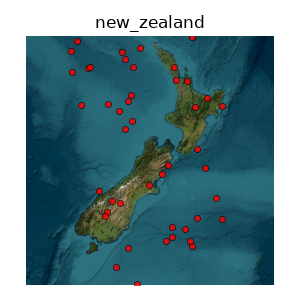

In [21]:
fig, ax = plot_points_on_saved_basemap(map_path, new_extents, df_meta, title=geo_name, figsize=(3,3))

## Check any existing label data

Check previous labels if they exist:

In [22]:
if paths.original_labels is not None and paths.original_labels.is_file:
    df_labels = load_labels(paths.original_labels)
    display(df_labels.head())

,Filename,Start Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),Label,Type,Sex,Score,Delta Time (s),Delta Freq (Hz),Avg Power Density (dB FS/Hz),Life Stage,Indv ID
0,20190831_083004_from_420.flac,37.6,45.0,1230.0,2365.0,weka1,<NA>,<NA>,NaN,7.4,1135.0,-53.0,<NA>,<NA>
1,20190831_181504_from_240.flac,54.5,60.0,997.0,2656.0,weka1,<NA>,<NA>,NaN,5.5,1659.0,-62.1,<NA>,<NA>
2,20190831_181504_from_300.flac,0.0,5.1,997.0,2656.0,weka1,<NA>,<NA>,NaN,5.1,1659.0,-61.2,<NA>,<NA>
3,20190831_181504_from_300.flac,10.3,37.8,1133.0,2655.0,weka1,<NA>,<NA>,NaN,27.5,1522.0,-62.2,<NA>,<NA>
4,20190831_181504_from_780.flac,13.4,49.5,444.0,8302.0,weka1,<NA>,<NA>,NaN,36.1,7858.0,-45.6,<NA>,<NA>


## Check the naming schema

In [23]:
if paths.naming_csv is not None and paths.naming_csv.is_file:
    df_naming = pd.read_csv(paths.naming_csv)
    display(df_naming.head())

,CommonName,eBird,ScientificName,ClassifyName,AnnotationGroup,OrderName
0,Northern Royal Albatross,norroal,Diomedea sanfordi,Northern Royal Albatross,Birds,Albatross
1,Bellbird,nezbel1,Anthornis melanura,Bellbird,Birds,Bellbird
2,Bellbird or Tui,bellbird_tui,Anthornis melanura or Prosthemadera novaeseela...,Bellbird-Tui,Fallback,Bellbird
3,Bird,bird,Aves,Bird,Fallback,Bird
4,Australasian Bittern,ausbit1,Botaurus poiciloptilus,Australasian Bittern,Birds,Bittern
